# Emotion Detection Project (FER2013)Pipeline includes:1. Data Loading2. Data Augmentation3. Improved CNN Model4. Training with Callbacks5. Evaluation + Confusion Matrix6. Transfer Learning (MobileNetV2)7. Model Comparison8. Webcam Emotion Detection DemoDataset structure expected:```dataset/   train/      angry/      happy/      sad/      ...   test/      angry/      happy/      sad/```

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

## Load Dataset

In [2]:
!pip install kaggle

In [3]:
from getpass import getpass
import os
import json

username = input("Enter your Kaggle username: ")
token = getpass("Enter your Kaggle API token: ")

kaggle_info = {
    "username": username,
    "key": token
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_info, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

print("kaggle.json created successfully!")

Enter your Kaggle username: aditi2006
Enter your Kaggle API token: ··········
kaggle.json created successfully!


In [4]:
!kaggle datasets download -d msambare/fer2013
!unzip -o fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [5]:
IMG_SIZE = (48,48)
BATCH_SIZE = 64
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "train",
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE
  )
test_data = tf.keras.preprocessing.image_dataset_from_directory(
      "test",
      image_size=IMG_SIZE,
      color_mode="grayscale",
      batch_size=BATCH_SIZE,
      shuffle=False)
class_names = train_data.class_names
print(class_names)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Augmentation

In [7]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ])

## Improved CNN Model

In [8]:
cnn_model = models.Sequential([
    layers.Input(shape=(48,48,1)),
    data_aug,
    layers.Conv2D(32,(3,3),padding="same",activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32,(3,3),padding="same",activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Conv2D(64,(3,3),padding="same",activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64,(3,3),padding="same",activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Conv2D(128,(3,3),padding="same",activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(256,activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(len(class_names),activation="softmax")
  ])
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
  )
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,79

 Total params: 1,322,855 (5.05 MB)

 Trainable params: 1,321,703 (5.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

## Training CNN

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
  )
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-5
  )
history = cnn_model.fit(
    train_data,
    validation_data=test_data,
    epochs=40,
    callbacks=[early_stop, reduce_lr]
  )

Epoch 1/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.2469 - loss: 2.2753 - val_accuracy: 0.3473 - val_loss: 1.7445 - learning_rate: 0.0010
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.3689 - loss: 1.6437 - val_accuracy: 0.2959 - val_loss: 2.0385 - learning_rate: 0.0010
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.4262 - loss: 1.4955 - val_accuracy: 0.4884 - val_loss: 1.3354 - learning_rate: 0.0010
Epoch 4/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.4567 - loss: 1.4135 - val_accuracy: 0.5081 - val_loss: 1.2928 - learning_rate: 0.0010
Epoch 5/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.4832 - loss: 1.3576 - val_accuracy: 0.5025 - val_loss: 1.3398 - learning_rate: 0.0010
Epoch 6/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.4928 - loss: 1.3272 - val_accuracy: 0.5116 - val_loss: 1.3909 - learning_rate: 0.0010
Epoch 7/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.5102 - l

## Save CNN Model

In [10]:
cnn_model.save("emotion_cnn_model.h5")

## Confusion Matrix

In [12]:
class_names_6 = ['angry','fear','happy','sad','surprise','neutral']

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━

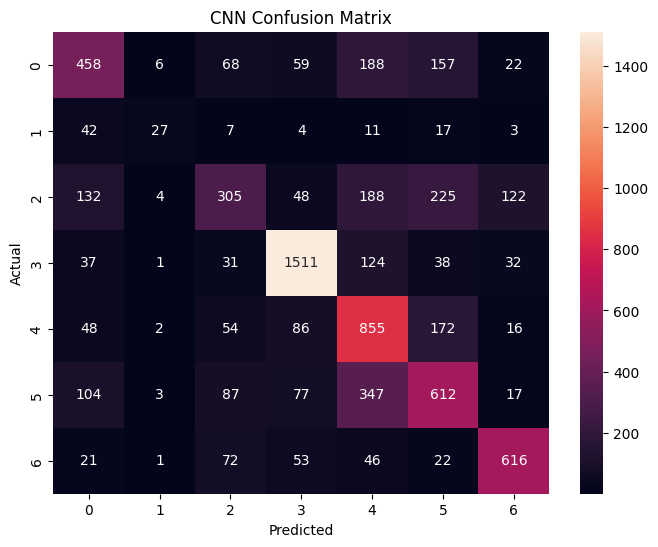

              precision    recall  f1-score   support

       angry       0.54      0.48      0.51       958
        fear       0.61      0.24      0.35       111
       happy       0.49      0.30      0.37      1024
         sad       0.82      0.85      0.84      1774
    surprise       0.49      0.69      0.57      1233
     neutral       0.49      0.49      0.49      1247

   micro avg       0.59      0.59      0.59      6347
   macro avg       0.57      0.51      0.52      6347
weighted avg       0.59      0.59      0.58      6347



In [14]:
y_true = []
y_pred = []

for images, labels in test_data:
    preds = cnn_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    labels=[0,1,2,3,4,5],
    target_names=class_names_6
))

## Transfer Learning (MobileNetV2)

In [15]:
IMG_SIZE_TL = (96,96)
train_tl = tf.keras.preprocessing.image_dataset_from_directory(
    "train",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
  )
test_tl = tf.keras.preprocessing.image_dataset_from_directory(
    "test",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
  )

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [16]:
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False

inputs = tf.keras.Input(shape=(96,96,3))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

tl_model = tf.keras.Model(inputs, outputs)

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,975 (9.26 MB)

 Trainable params: 167,431 (654.03 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [17]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [18]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [19]:
import numpy as np

y_train = []

for images, labels in train_data:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

In [20]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [21]:
class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [22]:
history_tl = tl_model.fit(
    train_tl,
    validation_data=test_tl,
    epochs=30,
    class_weight=class_weights
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 56s 84ms/step - accuracy: 0.1838 - loss: 2.3856 - val_accuracy: 0.2446 - val_loss: 1.8833
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.2250 - loss: 2.0051 - val_accuracy: 0.2846 - val_loss: 1.8347
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.2613 - loss: 1.8637 - val_accuracy: 0.2960 - val_loss: 1.7956
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.2792 - loss: 1.7844 - val_accuracy: 0.3112 - val_loss: 1.7651
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.2987 - loss: 1.7324 - val_accuracy: 0.3228 - val_loss: 1.7392
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.3135 - loss: 1.6947 - val_accuracy: 0.3330 - val_loss: 1.7232
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3261 - loss: 1.6637 - val_accuracy: 0.3388 - val_loss: 1.7114
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3365 - loss: 1.6173 - val_

## Save Transfer Learning Model

In [ ]:
tl_model.save("emotion_transfer_model.h5")

## Webcam Emotion Detection (OpenCV)

In [ ]:
import cv2
model = tf.keras.models.load_model("emotion_cnn_model.h5")
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
  )
cap = cv2.VideoCapture(0)
while True:
  ret, frame = cap.read()
  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray,1.3,5)
  for (x,y,w,h) in faces:
    face = gray[y:y+h,x:x+w]
    face = cv2.resize(face,(48,48))
    face = face/255.0
    face = np.reshape(face,(1,48,48,1))
    pred = model.predict(face)
    emotion = class_names[np.argmax(pred)]
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.putText(frame,emotion,(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2)
    cv2.imshow("Emotion Detector",frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
      breakcap.release()
      cv2.destroyAllWindows()